# Building Micrograd — Exercise Notebook

This guide is designed as a series of technical requirements following the chronological flow of the "Building Micrograd" lecture 1. To follow along with the official implementation, you can reference the micrograd/engine.py for the autograd engine and micrograd/nn.py for the neural network modules 2-4.

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Phase 1: Derivative Intuition & Numerical Gradients

### Exercise 1.1: The Scalar Function
Define a simple quadratic function $f(x) = 3x^2 - 4x + 5$ and plot it using matplotlib to understand its shape.

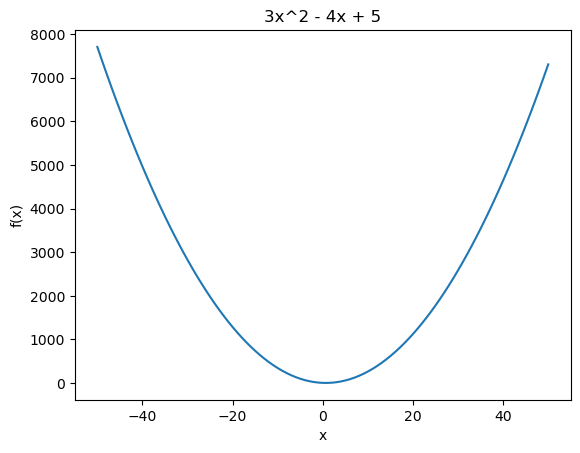

In [18]:
def f(x):
    return 3*x**2 - 4*x + 5 

x = np.arange(-50,51,1)
y = [f(i) for i in x]

plt.plot(x,y)
plt.title('3x^2 - 4x + 5')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
import matplotlib.pyplot as plt


def f(x):
    return 3 * x**2 - 4 * x + 5

x_values = [x / 10 for x in range(-50, 51)]
y_values = [f(x) for x in x_values]

plt.plot(x_values, y_values)
plt.title("f(x) = 3x^2 - 4x + 5")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()
```

#### Thorough explanation
This exercise establishes geometric intuition. The function $f(x)=3x^2-4x+5$ is a convex parabola, so plotting it gives immediate visual feedback on where slope is negative, zero, or positive.

From the technical guide, derivatives are interpreted as sensitivity: if slope is large and positive, a small increase in $x$ increases output strongly; if negative, output decreases. This intuition is foundational for why gradient-based optimization works.

Architecturally, this plot is not part of autograd itself; it is a calibration step that helps validate later numerical derivative estimates against the curve shape.

</details>

### Exercise 1.2: Numerical Approximation
Implement the mathematical definition of a derivative: $L = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$. Use a very small $h$ (e.g.,.0001) to numerically estimate the slope at various points.

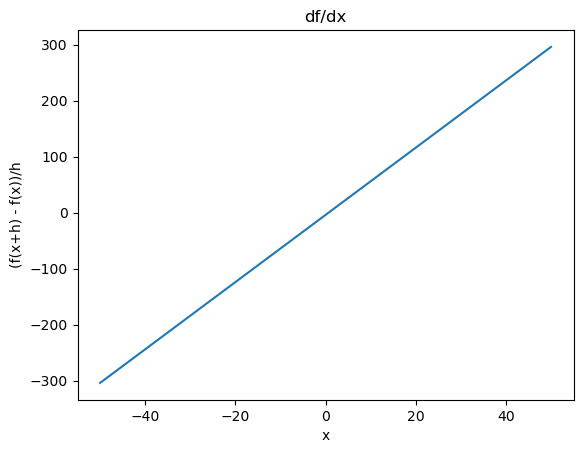

In [19]:
def df(x, h=1e-4):
    return (f(x+h) - f(x))/h

dy = [df(i) for i in x]

plt.plot(x,dy)
plt.title('df/dx')
plt.xlabel('x')
plt.ylabel('(f(x+h) - f(x))/h')
plt.show()

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
def f(x):
    return 3 * x**2 - 4 * x + 5


def numerical_derivative(func, x, h=1e-4):
    return (func(x + h) - func(x)) / h

for point in [-2.0, 0.0, 1.0, 2.0, 3.0]:
    print(point, numerical_derivative(f, point))
```

#### Thorough explanation
This is the finite-difference approximation of the derivative:
$f'(x) pprox rac{f(x+h)-f(x)}{h}$ for small $h$.

The answers guide emphasizes the trade-off: numerical derivatives are useful for gradient checking, but not efficient for training because each parameter perturbation requires additional forward evaluations.

Choosing $h$ is delicate:
- Too large: approximation error (poor local linearization)
- Too small: floating-point cancellation and instability

This is why analytical backpropagation is preferred in real training loops.

</details>

### Exercise 1.3: Multivariate Sensitivity
Create a function $d(a, b, c) = a \cdot b + c$. Numerically calculate the derivative of $d$ with respect to $a$, $b$, and $c$ individually by nudging each input by $h$ and observing the change in $d$.

In [23]:
def d(a,b,c):
    return a*b + c

h = 1e-6
a = 1
b = 2
c = 3

dyda = (d(a+h,b,c) - d(a,b,c))/h
dydb = (d(a,b+h,c) - d(a,b,c))/h
dydc = (d(a,b,c+h) - d(a,b,c))/h

print(dyda)
print(dydb)
print(dydc)

2.000000000279556
1.000000000139778
1.000000000139778


<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
def d(a, b, c):
    return a * b + c


def partial_derivative_wrt_a(a, b, c, h=1e-4):
    return (d(a + h, b, c) - d(a, b, c)) / h


def partial_derivative_wrt_b(a, b, c, h=1e-4):
    return (d(a, b + h, c) - d(a, b, c)) / h


def partial_derivative_wrt_c(a, b, c, h=1e-4):
    return (d(a, b, c + h) - d(a, b, c)) / h

print(partial_derivative_wrt_a(2.0, -3.0, 10.0))
print(partial_derivative_wrt_b(2.0, -3.0, 10.0))
print(partial_derivative_wrt_c(2.0, -3.0, 10.0))
```

#### Thorough explanation
For $d(a,b,c)=ab+c$, each partial derivative isolates one input while holding others constant:
$\partial d/\partial a = b$, $\partial d/\partial b = a$, $\partial d/\partial c = 1$.

The nudging approach demonstrates what "local sensitivity" means in practice and directly mirrors later chain-rule propagation where each local factor contributes to a global gradient.

This exercise also prepares the key mindset for DAGs: one output can depend on many inputs, and each path contributes information to parameter updates.

</details>

## Phase 2: Building the Value Object (Forward Pass)

### Exercise 2.1: The Wrapper
Create a Value class that initializes with a single scalar data attribute.

In [25]:
class Value:
    def __init__(self, data, label = ''):
        self.data = data

    def __repr__(self):
        return f"Value(data = {self.data})"
    
Value(2)

Value(data = 2)

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"
```

#### Thorough explanation
`Value` is the atomic data structure of Micrograd: a scalar plus autograd metadata.

Per the guide, the required state is:
- `data`: scalar payload
- `grad`: accumulated derivative of final loss wrt this node
- `_prev`: parents in the graph (as a set for uniqueness)
- `_op`: operation provenance label

This class boundary is critical: all operator overloads and gradient logic rely on the guarantee that every intermediate is represented as a `Value` node.

</details>

### Exercise 2.2: Basic Arithmetic
Implement Python "dunder" methods __add__ and __mul__ so you can perform a + b and a * b using Value objects.

In [27]:
class Value:
    def __init__(self, data, label = ''):
        self.data = data

    def __add__(self, other):
        return Value(self.data + other.data)
    
    def __mul__(self, other):
        return Value(self.data * other.data)

    def __repr__(self):
        return f"Value(data = {self.data})"
    
a = Value(2)
b = Value(4)

print(a+b)
print(a*b)

Value(data = 6)
Value(data = 8)


<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
```

#### Thorough explanation
Overloading `__add__` and `__mul__` creates graph nodes during forward pass and stores a closure (`_backward`) with local derivative logic.

The answers document stresses constant wrapping: if `other` is raw numeric, convert to `Value` so mixed expressions preserve graph consistency.

This is the first place where local derivative rules are encoded:
- addition routes gradient (factor 1)
- multiplication applies the opposite operand

These local rules become global through reverse traversal later.

</details>

### Exercise 2.3: Tracking the Graph
Update your Value class to store a _prev set (the "children" or inputs that created the value) and an _op string (the operation used, e.g., '+' or '*').

In [6]:
class Value:
    def __init__(self, data, _prev=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_prev)
        self._op = _op
        self.label = label

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self,other), '+')
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self,other), '*')

    def __repr__(self):
        return f"Value(data = {self.data})"
    
a = Value(2)
b = Value(4)

print(a+b)
print(a*b)

Value(data = 6)
Value(data = 8)


<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
```

#### Thorough explanation
Tracking `_prev` and `_op` transforms plain scalar arithmetic into a traceable computation graph.

`_prev` supports graph traversal and topological sorting; `_op` provides operation-level provenance useful for debugging and visualization.

The guide frames this as state management for autograd: without parent links, there is no backward path; without operation context, there is no interpretable graph diagnostics.

</details>

### Exercise 2.4: Visualization (Optional)
Implement or copy the draw_dot function to visualize your computation graphs using Graphviz.

In [1]:
from graphviz import Digraph
import os

os.environ["PATH"] = r"C:\Users\I0567922\tools\graphviz\bin;" + os.environ["PATH"]
os.environ["GRAPHVIZ_DOT"] = r"C:\Users\I0567922\tools\graphviz\bin\dot.exe"

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


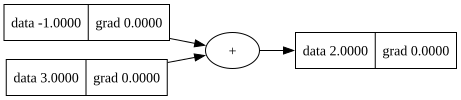

In [8]:
a = Value(-1)
b = Value(3)

c = a + b
draw_dot(c)

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
from graphviz import Digraph


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label=f"{{ data {n.data:.4f} | grad {n.grad:.4f} }}", shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot
```

#### Thorough explanation
`draw_dot` is a graph debugger. It traverses parent pointers (`_prev`) to produce a DAG view of both values and operation nodes.

The practical value is verification:
- forward dependencies are correct
- backward routing should follow the same topology in reverse

For complex expressions, visualization is often the fastest way to spot missing edges, duplicated nodes, or incorrect operation chaining.

</details>

## Phase 3: Manual Backpropagation & The Chain Rule

### Exercise 3.1: The Gradient Attribute
Add a grad attribute to your Value class, initialized to.0.

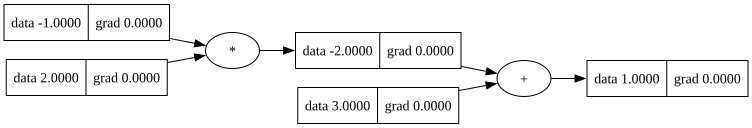

In [23]:
a = Value(2)
b = Value(-1)
c = a*b
d = Value(3)

L = c + d 
draw_dot(L)

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None
```

#### Thorough explanation
Initializing `grad = 0.0` is a mathematical and implementation prerequisite for accumulation.

The guide repeatedly highlights that in DAGs, multiple paths can contribute to the same variable. A zero baseline enables additive updates (`+=`) from each path during backprop.

Without this initialization, gradient accumulation semantics become undefined and multivariate cases fail.

</details>

### Exercise 3.2: Manual Backprop on Scalars
Build a small expression (e.g., $L = d \cdot f$) and manually fill in the .grad values for every node by working backward from $L$ ($dL/dL = 1$).

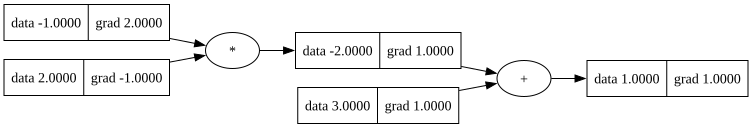

In [24]:
L.grad = 1.0 
d.grad = 1.0 * L.grad
c.grad = 1 * L.grad
a.grad = b.data * c.grad
b.grad = a.data * c.grad

draw_dot(L)

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
d = a * b; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

L.grad = 1.0

d.grad = f.data * L.grad
f.grad = d.data * L.grad

a.grad = b.data * d.grad
b.grad = a.data * d.grad

print(a.grad, b.grad, c.grad, d.grad, f.grad, L.grad)
```

#### Thorough explanation
This exercise manually executes reverse-mode differentiation from the seed $dL/dL=1$.

You compute each node’s gradient by multiplying upstream gradient with local derivative. Doing this by hand demonstrates exactly what `_backward` closures and `backward()` automate later.

It also makes gradient direction tangible: sign and magnitude changes correspond to how each local operation transforms sensitivity.

</details>

### Exercise 3.3: Applying the Chain Rule
For each operation, calculate the local derivative and multiply it by the global derivative (the gradient of the next node).

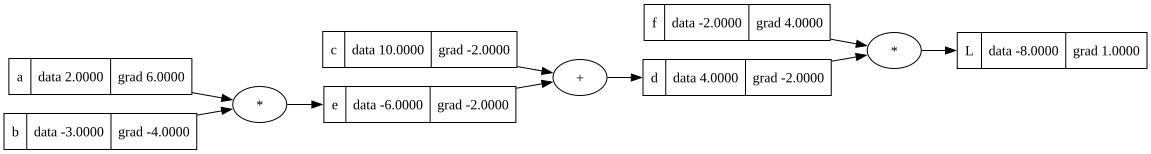

In [7]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

# dL / dL
L.grad = 1.0

# dL / dd = (dL / dd) * (dL / dL)
d.grad = f.data * L.grad

# dL / df = (dL / df) * (dL / dL)
f.grad = d.data * L.grad

# dL / de =  (dd / de) * (dL / dd)
e.grad = 1.0 * d.grad

# dL / dc =  (dd / dc) * (dL / dd)
c.grad = 1.0 * d.grad

# dL / da = (de / da) * (dL / de)
a.grad = b.data * e.grad

# dL / db = (de / db) * (dL / de)
b.grad = a.data * e.grad

draw_dot(L)

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

L.grad = 1.0

d.grad = f.data * L.grad
f.grad = d.data * L.grad

e.grad = 1.0 * d.grad
c.grad = 1.0 * d.grad

a.grad = b.data * e.grad
b.grad = a.data * e.grad
```

#### Thorough explanation
Backpropagation is repeated chain-rule composition:
$rac{dL}{dx}=rac{dL}{dy}rac{dy}{dx}$.

The guide’s local-derivative table is the operative mechanism:
- Add: local factor 1
- Mul: local factor equals opposite input
- Tanh: local factor $1-t^2$

Global gradients emerge by multiplying these local factors along every path from loss to variable.

</details>

### Task: Addition Node Gradient Routing
Verify that an Addition node simply "routes" the gradient.

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
# For y = x1 + x2, local derivatives are dy/dx1 = 1 and dy/dx2 = 1.
# So if y.grad is known, then:
# x1.grad += 1.0 * y.grad
# x2.grad += 1.0 * y.grad
```

#### Thorough explanation
For $y=x_1+x_2$, local derivatives are both 1, so upstream gradient is copied unchanged to each input.

This is why addition nodes act as routers: they duplicate gradient flow, preserving magnitude unless downstream paths scale it later.

</details>

### Task: Multiplication Node Gradient Behavior
Verify that a Multiplication node "switches" the values and multiplies them by the gradient.

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
# For y = x1 * x2, local derivatives are dy/dx1 = x2 and dy/dx2 = x1.
# So if y.grad is known, then:
# x1.grad += x2.data * y.grad
# x2.grad += x1.data * y.grad
```

#### Thorough explanation
For $y=x_1x_2$, local derivatives are switched inputs:
$\partial y/\partial x_1=x_2$ and $\partial y/\partial x_2=x_1$.

So each input receives upstream gradient scaled by the opposite operand; this is the canonical product-rule behavior encoded in scalar reverse-mode.

</details>

## Phase 4: Automatic Backpropagation

### Exercise 4.1: The _backward Closure
Inside __add__, __mul__, and other operations, define an internal _backward function that performs the chain rule step for that specific operation and store it as an attribute on the output node.

In [11]:
class Value:
    def __init__(self, data, _prev=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self.label = label
        self._prev = set(_prev)
        self._op = _op
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), '+')
    
        def _backward():
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad 

        out._backward = _backward

        return out

    def __repr__(self):
        return f"Value(data = {self.data})"

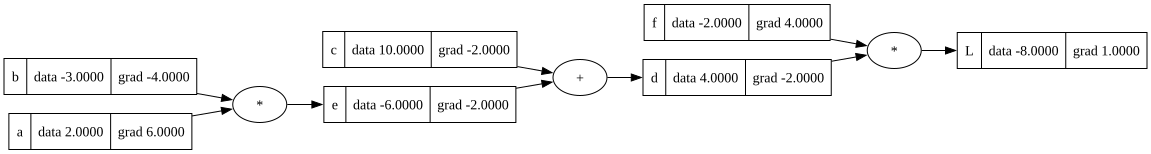

In [14]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

L.grad = 1.0
L._backward()
d._backward()
e._backward()

draw_dot(L)

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
        self.grad += 1.0 * out.grad
        other.grad += 1.0 * out.grad

    out._backward = _backward
    return out


def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
        self.grad += other.data * out.grad
        other.grad += self.data * out.grad

    out._backward = _backward
    return out
```

#### Thorough explanation
A closure stores operation-specific backward logic together with the exact forward-time context (`self`, `other`, `out`).

This is crucial because during global backward traversal, we no longer recompute forward expressions; each node simply executes its stored local gradient contribution.

The design keeps autograd modular: each primitive operation owns its local derivative rule.

</details>

### Exercise 4.2: Complex Operations
Implement the tanh activation function and its local derivative: $\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x)$.

In [ ]:
class Value:
    def __init__(self, data, _prev=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self.label = label
        self._prev = set(_prev)
        self._op = _op
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), '+')
    
        def _backward():
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad 

        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,),'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward
        return out

    def __repr__(self):
        return f"Value(data = {self.data})"

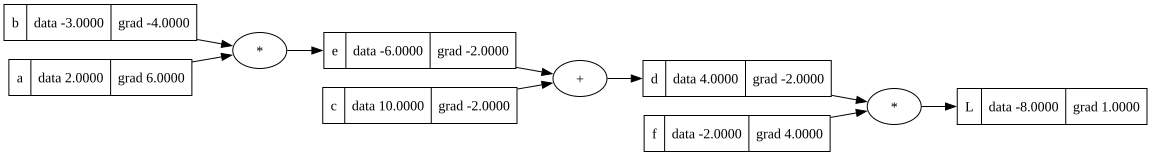

In [16]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'

L.backward()

draw_dot(L)

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
import math


def tanh(self):
    x = self.data
    t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
    out = Value(t, (self,), 'tanh')

    def _backward():
        self.grad += (1 - t**2) * out.grad

    out._backward = _backward
    return out
```

#### Thorough explanation
Implementing `tanh` introduces a nonlinearity and its derivative.

The guide recommends using forward output $t=	anh(x)$ directly in backward as $(1-t^2)$ for efficiency and numerical clarity.

Nonlinear activations are essential: without them, stacked layers collapse to a single linear transform and lose expressive capacity.

</details>

### Exercise 4.3: Topological Sort
Implement a function that performs a topological sort on your computation graph so that nodes are ordered such that no node is processed until all its "consumers" have been processed.

In [ ]:
topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
def build_topo(v, visited, topo):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child, visited, topo)
        topo.append(v)
```

#### Thorough explanation
Correct backward execution order requires topological sorting of the computation DAG.

DFS post-order append yields an ordering where dependencies appear before dependents in forward direction; reversing this order supports correct gradient propagation from loss to leaves.

Without this ordering, a node might consume incomplete upstream gradients.

</details>

### Exercise 4.4: The backward() Method
Create a top-level backward() method that:
- Sets the root node's gradient to.0.
- Applies the topological sort.
- Calls _backward() on every node in reverse order.

In [15]:
class Value:
    def __init__(self, data, _prev=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self.label = label
        self._prev = set(_prev)
        self._op = _op
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), '+')
    
        def _backward():
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad 

        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,),'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

    def __repr__(self):
        return f"Value(data = {self.data})"

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
def backward(self):
    topo = []
    visited = set()

    def build_topo(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)

    build_topo(self)
    self.grad = 1.0

    for node in reversed(topo):
        node._backward()
```

#### Thorough explanation
`backward()` orchestrates the full reverse-mode pipeline:
1) Build topo order
2) Seed root with gradient 1.0
3) Execute `_backward` in reverse topo

This is the minimal but complete autograd engine loop. It decouples graph construction (forward) from gradient propagation (reverse).

</details>

### Exercise 4.5: The Multivariate Bug
Ensure that gradients accumulate (use += instead of =) when a single variable is used more than once in an expression.

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
# Critical fix: gradients must accumulate, not overwrite.
# Wrong:
# self.grad = local_grad * out.grad
# Correct:
# self.grad += local_grad * out.grad
#
# Example: b = a + a should give db/da = 2.
```

#### Thorough explanation
The key bug is assignment vs accumulation when variables fan out.

Example: $b=a+a$ should produce $db/da=2$. If using `=`, one contribution overwrites the other; with `+=`, both contributions are summed.

The guide identifies this as the most critical correctness condition for autograd on DAGs.

</details>

## Phase 5: Refining the Engine

### Exercise 5.1: Constant Support
Update __add__ and __mul__ to handle cases where the other operand is a raw int or float. Implement __radd__ and __rmul__ to handle reversed operations like 2 * a.

In [40]:
class Value:
    def __init__(self, data, _prev=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self.label = label
        self._prev = set(_prev)
        self._op = _op
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), '+')
    
        def _backward():
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad 

        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self*other
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,),'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

    def __repr__(self):
        return f"Value(data = {self.data})"

In [43]:
print(2 + Value(4))
print(2* Value(4))

Value(data = 6)
Value(data = 8)


<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
        self.grad += 1.0 * out.grad
        other.grad += 1.0 * out.grad

    out._backward = _backward
    return out


def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
        self.grad += other.data * out.grad
        other.grad += self.data * out.grad

    out._backward = _backward
    return out


def __radd__(self, other):
    return self + other


def __rmul__(self, other):
    return self * other
```

#### Thorough explanation
Ergonomics and correctness both require numeric interoperability.

Wrapping non-`Value` operands in `__add__`/`__mul__` keeps graph creation consistent. `__radd__` and `__rmul__` handle expressions where Python dispatch starts from a raw numeric on the left (e.g., `2 * a`).

This closes an API usability gap and aligns behavior with PyTorch-like operator expectations.

</details>

### Exercise 5.2: Power & Division
Implement a generic __pow__ method. Then, define __truediv__ as a combination of pow and mul ($a / b = a \cdot b^{-1}$).

In [65]:
import math

class Value:
    def __init__(self, data, _prev=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self.label = label
        self._prev = set(_prev)
        self._op = _op
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), '+')
    
        def _backward():
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad 

        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self*other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,),f'**{other}')

        def _backward():
            self.grad += ((other * self.data) ** (other - 1)) * out.grad
    
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        return self * (other ** -1)
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,),'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

    def __repr__(self):
        return f"Value(data = {self.data})"

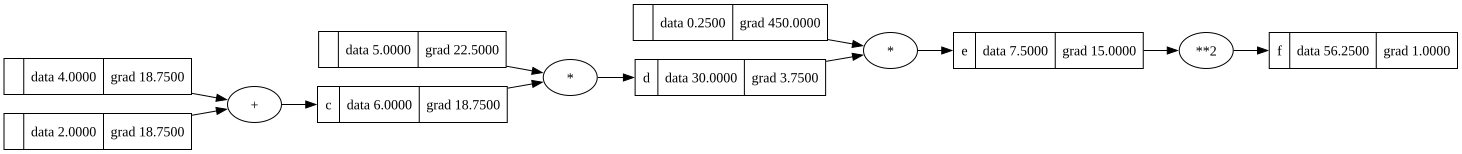

In [61]:
a = Value(2)
b = Value(4)

c = a + b ; c.label = 'c'
d = 5 * c ; d.label = 'd'
e = d / 4 ; e.label = 'e'
f = e ** 2 ; f.label = 'f'

f.grad = 1.0
f.backward()

draw_dot(f)

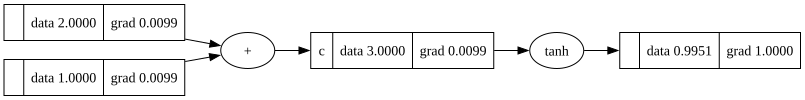

In [63]:
a = Value(1)
b = Value(2)

c = a + b ; c.label = 'c'
L = c.tanh()

L.backward()
draw_dot(L)

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
def __pow__(self, other):
    assert isinstance(other, (int, float)), 'only supporting int/float powers for now'
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += (other * self.data**(other - 1)) * out.grad

    out._backward = _backward
    return out


def __truediv__(self, other):
    return self * (other**-1)
```

#### Thorough explanation
`__pow__` introduces reusable scalar exponentiation with power-rule derivative
$rac{d}{dx}(x^n)=nx^{n-1}$.

The guide’s compositional principle applies: division is derived, not atomic,
$a/b = a\cdot b^{-1}$.

By building complex ops from existing primitives, you reduce new backward logic surface area and improve maintainability.

</details>

### Exercise 5.3: Subtraction
Define __neg__ (negation) and __sub__ using addition and negation ($a - b = a + (-b)$).

In [4]:
import math

class Value:
    def __init__(self, data, _prev=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self.label = label
        self._prev = set(_prev)
        self._op = _op
        self._backward = lambda: None

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self,other), '+')
    
        def _backward():
            self.grad += 1.0 * out.grad 
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out
    
    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad 

        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,),f'**{other}')

        def _backward():
            self.grad += ((other * self.data) ** (other - 1)) * out.grad
    
        out._backward = _backward
        return out
    
    def __truediv__(self, other):
        return self * (other ** -1)
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):
        return Value(other) - self
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self,),'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        
        out._backward = _backward
        return out
    
    def exp(self):
        out = Value(math.exp(self.data), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)
        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

    def __repr__(self):
        return f"Value(data = {self.data})"

In [12]:
print(- Value(1))
print(Value(2) - Value(1))
print(Value(2).exp())
print(1 - Value(2))
print(1 + Value(2))
print(Value(2) - 3)
print(Value(2)*4)
print(-1*Value(2))

Value(data = -1)
Value(data = 1)
Value(data = 7.38905609893065)
Value(data = -1)
Value(data = 3)
Value(data = -1)
Value(data = 8)
Value(data = -2)


<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
def __neg__(self):
    return self * -1


def __sub__(self, other):
    return self + (-other)
```

#### Thorough explanation
Subtraction is implemented compositionally:
- negation: `-b = b * -1`
- subtraction: `a - b = a + (-b)`

This avoids introducing a separate subtraction primitive and automatically reuses existing tested addition/multiplication gradient paths.

</details>

## Phase 6: Building the Neural Network (nn.py)

### Exercise 6.0: Implement the Smallest Possible MLP

Write Python code to implement a single neuron (the smallest possible Multi-Layer Perceptron) that computes the following:

1. **Inputs**: Two scalar values, \( x_1 \) and \( x_2 \), representing the inputs to the neuron.  
2. **Weights**: Two scalar values, \( w_1 \) and \( w_2 \), representing the weights for each input.  
3. **Bias**: A scalar value \( b \), representing the bias of the neuron.  
4. **Neuron Output**: Compute the output of the neuron as:  
   $$
   o = \tanh(x_1 \cdot w_1 + x_2 \cdot w_2 + b)
   $$
   where \( \tanh \) is the hyperbolic tangent activation function.

**Requirements**:
- Use the `Value` class to represent all inputs, weights, and intermediate computations.
- Label each intermediate computation (e.g., \( x_1 \cdot w_1 \), \( x_2 \cdot w_2 \), etc.) using the `label` attribute of the `Value` class.
- The final output \( o \) should also be labeled as `"o"`.

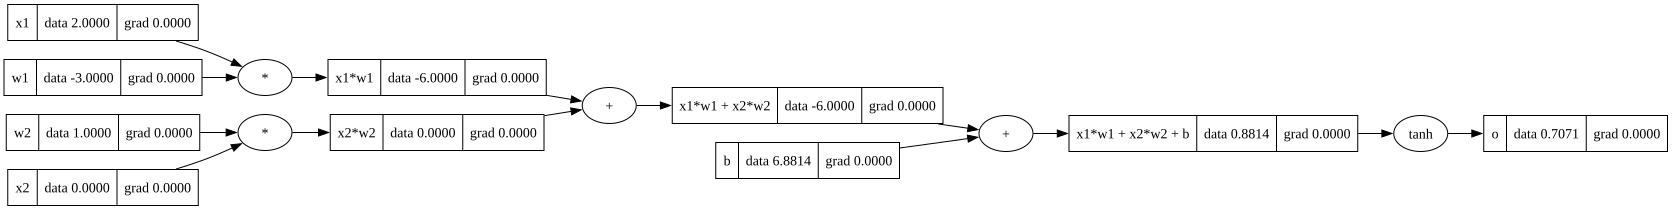

In [89]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b ; n.label = 'x1*w1 + x2*w2 + b'
o = n.tanh() ; o.label = 'o'

draw_dot(o)

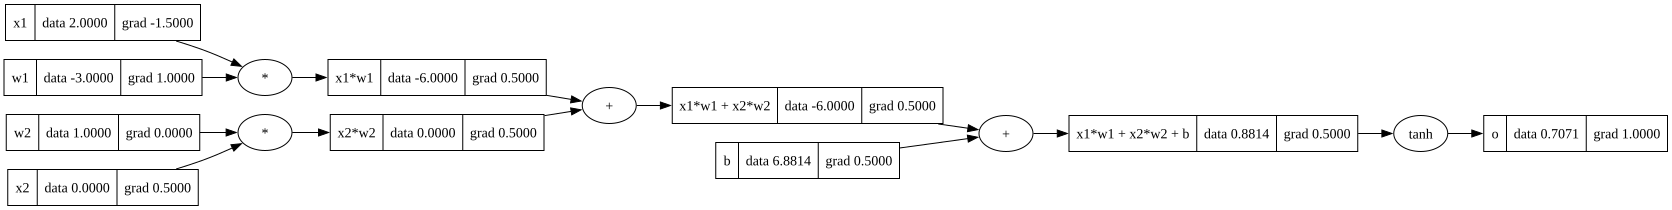

In [90]:
o.backward()
draw_dot(o)

In [93]:
# reseting the gradients to do backprop step by step now
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b ; n.label = 'x1*w1 + x2*w2 + b'
o = n.tanh() ; o.label = 'o'

In [94]:
topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)

build_topo(o)
topo

[Value(data = 6.881373587019543),
 Value(data = -3.0),
 Value(data = 2.0),
 Value(data = -6.0),
 Value(data = 0.0),
 Value(data = 1.0),
 Value(data = 0.0),
 Value(data = -6.0),
 Value(data = 0.8813735870195432),
 Value(data = 0.7071067811865476)]

### Exercise 6.1: The Neuron
Create a Neuron class that initializes with $n$ weights and 1 bias. Implement the forward pass: $f(x) = \tanh(\sum w_i x_i + b)$.

In [13]:
import random

class Neuron:

    def __init__(self, nin, _bias = 0.0):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(_bias)

    def __call__(self, x):
        a = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return a.tanh()
    
    def parameters(self):
        return self.w + [self.b]


In [105]:
n = Neuron(4)
print(n([1,2,3,4]))
n.parameters()

Value(data = -0.9999181619290046)


[Value(data = 0.16263330929004094),
 Value(data = -0.8674125697537385),
 Value(data = -0.6875045842838414),
 Value(data = -0.3543078876983643),
 Value(data = 0.0)]

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
import random
import math


class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]
```

#### Thorough explanation
A neuron computes affine transform plus nonlinearity:
$	anh(\sum_i w_i x_i + b)$.

The guide highlights initialization and parameter exposure:
- weights initialized randomly
- bias initialized explicitly
- parameters returned for optimization

This defines the smallest trainable unit in the `nn.py` hierarchy.

</details>

### Exercise 6.2: The Layer
Create a Layer class that contains a list of independent Neurons.

In [14]:
class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        params = []
        for n in self.neurons:
            params.extend(n.parameters())
        return params 

In [110]:
l = Layer(3,2)
l.parameters()

[Value(data = -0.7427412266605866),
 Value(data = 0.9466675678006611),
 Value(data = -0.4734016887270609),
 Value(data = 0.0),
 Value(data = 0.9610970777608121),
 Value(data = 0.9571620982545339),
 Value(data = -0.05429756086944604),
 Value(data = 0.0)]

In [111]:
l([1,2,3])

[Value(data = -0.2632629794525842), Value(data = 0.9912290060539415)]

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for n in self.neurons:
            params.extend(n.parameters())
        return params
```

#### Thorough explanation
A layer is a collection of independent neurons receiving the same input vector.

Implementation returns either a scalar output (single-neuron layer) or list, matching common micrograd conventions and simplifying downstream MLP composition.

Parameter collection should aggregate all child neuron parameters into one flat list.

</details>

### Exercise 6.3: The MLP
Create an MLP (Multi-Layer Perceptron) class that stacks multiple Layers sequentially.

In [15]:
class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
           x = layer(x) 
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [124]:
mlp = MLP(2,[3,1])
mlp([1,1])

Value(data = 0.049362115230063966)

In [125]:
mlp.parameters()

[Value(data = 0.16223212121172215),
 Value(data = 0.8024463299673359),
 Value(data = 0.0),
 Value(data = 0.3454710539296524),
 Value(data = -0.9495040920797015),
 Value(data = 0.0),
 Value(data = -0.5186239848205398),
 Value(data = -0.08973904724770376),
 Value(data = 0.0),
 Value(data = -0.16687516980565587),
 Value(data = -0.32386953955570075),
 Value(data = 0.0016774386711573275),
 Value(data = 0.0)]

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
```

#### Thorough explanation
An MLP stacks layers sequentially; each layer consumes the previous output.

The guide frames this as recursive piping. A concise `parameters()` flattening over layers enables optimizer loops to treat the network as one trainable parameter set.

This composition mirrors the architectural pattern used in larger deep learning frameworks.

</details>

### Exercise 6.4: Parameter Collection
Add a parameters() method to Neuron, Layer, and MLP that recursively collects all Value objects representing weights and biases.

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0


class Neuron(Module):
    def parameters(self):
        return self.w + [self.b]


class Layer(Module):
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]


class MLP(Module):
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
```

#### Thorough explanation
A shared `Module` interface supports recursive parameter management and gradient reset.

`parameters()` on each level (Neuron → Layer → MLP) returns all trainable `Value` objects. This is what enables generic training code to iterate over parameters without model-specific logic.

This abstraction is key for scaling from single neuron demos to multi-layer networks.

</details>

## Phase 7: The Training Loop

### Exercise 7.1: Loss Function
Implement a Mean Squared Error (MSE) loss that calculates the difference between your MLP predictions and ground truth targets.

In [16]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

mlp = MLP(3,[4, 4, 1])

ypreds = [mlp(x) for x in xs]

loss = sum([(ytrue - ypred)**2 for ytrue, ypred in zip(ys,ypreds)])
loss

Value(data = 3.777034668814922)

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
# Mean Squared Error (sum form)
ypred = [n(x) for x in xs]
loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
```

#### Thorough explanation
MSE provides a differentiable scalar objective:
$\sum (y_{pred}-y_{target})^2$.

Because loss is a `Value`, calling `backward()` propagates gradients all the way into network weights and biases.

This ties prediction quality directly to trainable parameters through the autograd graph.

</details>

### Exercise 7.2: Zero Grad
Implement a step to reset all parameter gradients to.0 before every backward pass to avoid accumulation across different training steps.

In [17]:
## forward pass 
ypreds = [mlp(x) for x in xs]
loss = sum([(ytrue - ypred)**2 for ytrue, ypred in zip(ys,ypreds)])

## backward pass
for p in mlp.parameters():
    p.grad = 0.0
loss.backward()

loss

Value(data = 3.777034668814922)

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
for p in n.parameters():
    p.grad = 0.0
```

#### Thorough explanation
With accumulation semantics (`+=`), gradients persist unless manually reset.

The guide marks this as a frequent training bug: failing to zero grads blends history from previous steps and corrupts updates.

Correct loop order always includes gradient reset before each backward pass.

</details>

### Exercise 7.3: Gradient Descent
Implement the weight update step: $weight = weight - (step\_size \cdot weight.grad)$.

In [23]:
## forward pass 
ypreds = [mlp(x) for x in xs]
loss = sum([(ytrue - ypred)**2 for ytrue, ypred in zip(ys,ypreds)])

## backward pass
for p in mlp.parameters():
    p.grad = 0.0
loss.backward()

## gradient decent
for p in mlp.parameters():
    p.data = p.data - 0.05*p.grad

loss

Value(data = 1.7324142053213718)

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
step_size = 0.05
for p in n.parameters():
    p.data += -step_size * p.grad
```

#### Thorough explanation
Parameter update applies SGD:
`p.data = p.data - lr * p.grad`.

Learning rate controls step magnitude. Too large can overshoot minima and destabilize training; too small slows convergence.

This is where computed gradients become actual parameter motion in loss-minimizing direction.

</details>

### Exercise 7.4: Optimization Loop
Combine everything into a loop:
- Forward Pass: Compute predictions and loss.
- Zero Grad: Reset gradients.
- Backward Pass: Call loss.backward().
- Update: Nudge parameters in the opposite direction of the gradient.

In [58]:
for k in range(1000):
    ## forward pass 
    ypreds = [mlp(x) for x in xs]
    loss = sum([(ytrue - ypred)**2 for ytrue, ypred in zip(ys,ypreds)])

    ## backward pass
    for p in mlp.parameters():
        p.grad = 0.0
    loss.backward()

    ## gradient decent
    for p in mlp.parameters():
        p.data = p.data - 0.1*p.grad

    print((k,loss))

(0, Value(data = 0.004063222773193357))
(1, Value(data = 0.003991144779190889))
(2, Value(data = 0.003921530959234051))
(3, Value(data = 0.0038542579355501025))
(4, Value(data = 0.003789210405714746))
(5, Value(data = 0.003726280493623529))
(6, Value(data = 0.003665367162023464))
(7, Value(data = 0.003606375679900843))
(8, Value(data = 0.0035492171388425064))
(9, Value(data = 0.003493808013197721))
(10, Value(data = 0.00344006975948348))
(11, Value(data = 0.003387928451009571))
(12, Value(data = 0.0033373144441641842))
(13, Value(data = 0.0032881620732066862))
(14, Value(data = 0.0032404093707676116))
(15, Value(data = 0.0031939978115653744))
(16, Value(data = 0.003148872077122388))
(17, Value(data = 0.003104979839500451))
(18, Value(data = 0.003062271562287253))
(19, Value(data = 0.0030207003172497966))
(20, Value(data = 0.0029802216152359368))
(21, Value(data = 0.0029407932500490046))
(22, Value(data = 0.002902375154150138))
(23, Value(data = 0.0028649292651562156))
(24, Value(data =

In [59]:
ypreds

[Value(data = 0.9939043537875804),
 Value(data = -0.9954046550552003),
 Value(data = -0.9912057878714878),
 Value(data = 0.9920148233621501)]

<details>
<summary><strong>Hidden solution + thorough explanation</strong> (click to expand)</summary>

#### Reference code
```python
# Assume xs (inputs), ys (targets), and n (MLP model) are defined.
for k in range(100):
    # Forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))

    # Zero grad
    for p in n.parameters():
        p.grad = 0.0

    # Backward pass
    loss.backward()

    # Update
    step_size = 0.05
    for p in n.parameters():
        p.data += -step_size * p.grad
```

#### Thorough explanation
The full training cycle is:
1) forward pass and loss
2) zero gradients
3) backward pass
4) parameter update

The answers file stresses strict sequencing and repetition to convergence. This loop is the operational integration point of all prior phases (graph build, autograd, parameter collection, and update rule).

</details>